In [67]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import random
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [47]:
X_train = np.load("../processed_data/X_train.npy")
X_val   = np.load("../processed_data/X_val.npy")
X_test  = np.load("../processed_data/X_test.npy")

y_train = np.load("../processed_data/y_train.npy")
y_val   = np.load("../processed_data/y_val.npy")
y_test  = np.load("../processed_data/y_test.npy")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (2711, 2048)
X_val: (539, 2048)
X_test: (539, 2048)
y_train: (2711,)
y_val: (539,)
y_test: (539,)


In [ ]:
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

X_train = X_train[:, :, np.newaxis]
X_val   = X_val[:, :, np.newaxis]
X_test  = X_test[:, :, np.newaxis]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

X_train: (2711, 2048, 1)
X_val: (539, 2048, 1)
X_test: (539, 2048, 1)
X_train dtype: float32
y_train dtype: int64


In [50]:
class BearingData(Dataset):
    def __init__(self, signals, labels):
        self.signals = signals
        self.labels = labels

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        signals = torch.tensor(self.signals[idx], dtype=torch.float32)
        labels = torch.tensor(self.labels[idx], dtype=torch.long)

        return signals, labels

In [51]:
train_dataset = BearingData(X_train, y_train)
val_dataset = BearingData(X_val, y_val)
test_dataset = BearingData(X_test, y_test)

In [52]:
signal, label = train_dataset[0]

print(signal.shape)
print(label)
print(signal.dtype)
print(label.dtype)

torch.Size([2048, 1])
tensor(1)
torch.float32
torch.int64


In [54]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [56]:
X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

X batch shape: torch.Size([32, 2048, 1])
y batch shape: torch.Size([32])


In [90]:
class BearingRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size1=128, hidden_size2=64, num_classes=10):
        super(BearingRNN, self).__init__()
    
        self.rnn1 = nn.RNN(
            input_size = input_size,
            hidden_size = hidden_size1,
            num_layers = 1,
            batch_first=True
        )

        self.rnn2 = nn.RNN(
            input_size = hidden_size1,
            hidden_size = hidden_size2,
            num_layers = 1,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size2, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        out, _ = self.rnn1(x)
        out, _ = self.rnn2(out)

        out = out[:, -1, :]

        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)

        return out


In [91]:
model = BearingRNN().to(device)
print(model)

BearingRNN(
  (rnn1): RNN(1, 128, batch_first=True)
  (rnn2): RNN(128, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)


In [59]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [60]:
epochs = 300

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

In [ ]:
print("Training Started")

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for signals, labels in train_loader:
        signals = signals.to(device)
        labels = labels.to(device)

        outputs = model(signals)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*signals.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    print("\nValidation Started\n") 

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for signals, labels in val_loader:
            signals = signals.to(device)
            labels = labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)

            running_loss += loss.item()*signals.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        val_loss = running_loss / total
        val_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(model.state_dict(),"best_RNN_weights.pth")

            print(f"New best validation loss: {best_val_loss:.4f}")
            print("------Model saved-----")

        print(f"Epoch [{epoch+1}/{epochs}] ")
        print(f"Train Loss: {train_loss:.4f} ")
        print(f"Train Acc: {train_accuracy:.2f}% ")
        print(f"Val Loss: {val_loss:.4f} ")
        print(f"Val Acc: {val_accuracy:.2f}%")

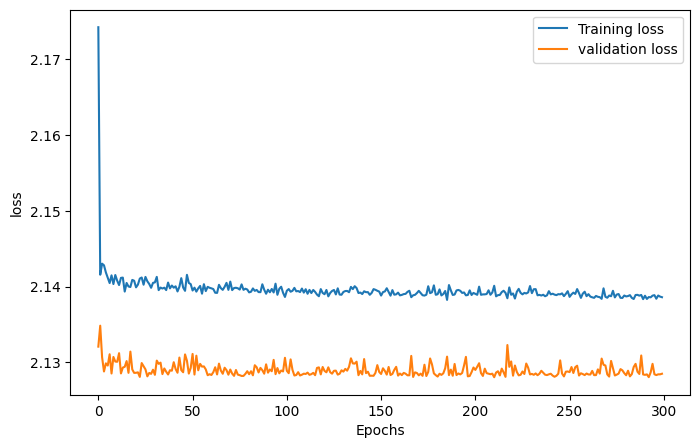

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('loss')

plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load("../../TCN/models/best_RNN_weights.pth", weights_only=True))

model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for signals, labels in test_loader:

        signals = signals.to(device)
        labels = labels.to(device)

        outputs = model(signals)
        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

Test Accuracy: 22.63%


# **LSTM MODEL FOR CWRU DATASET**

In [69]:
class BearingLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size1=128, hidden_size2=64, num_classes=10):
        super(BearingLSTM, self).__init__()
    
        self.lstm1 = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size1,
            num_layers = 1,
            batch_first=True
        )

        self.lstm2 = nn.LSTM(
            input_size = hidden_size1,
            hidden_size = hidden_size2,
            num_layers = 1,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, num_classes)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)

        out = out[:, -1, :]

        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)

        return out

In [74]:
model = BearingLSTM().to(device)
print(model)

BearingLSTM(
  (lstm1): LSTM(1, 128, batch_first=True)
  (lstm2): LSTM(128, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=10, bias=True)
)


In [33]:
signals, labels = next(iter(train_loader))

signals = signals.to(device)

outputs = model(signals)

print("Input shape:", signals.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 2048, 1])
Output shape: torch.Size([32, 10])


In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
epochs = 300

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

In [ ]:
print("Training Started")

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for signals, labels in train_loader:

        signals = signals.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(signals)
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * signals.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    print("\nValidation Started\n")

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for signals, labels in val_loader:

            signals = signals.to(device)
            labels = labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * signals.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_loss = running_loss / total
        val_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(),"best_LSTM_weights.pth")

        print(f"New best validation loss: {best_val_loss:.4f}")
        print("------Model saved-----")

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_accuracy:.2f}%")

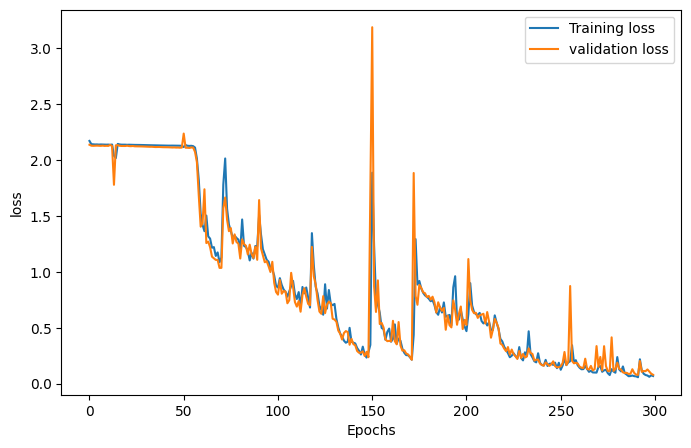

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('loss')

plt.legend()
plt.show()

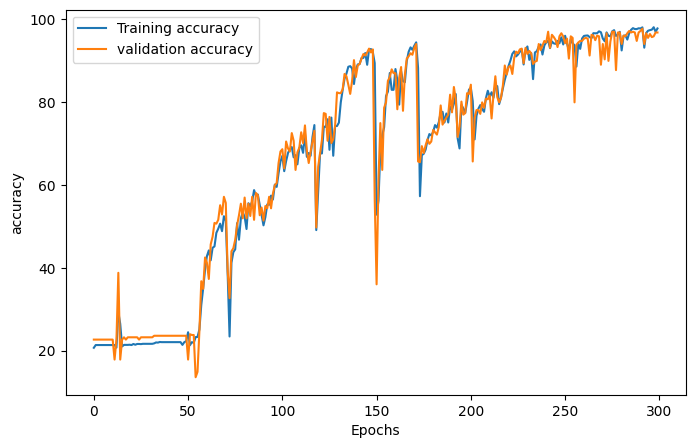

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label='Training accuracy')
plt.plot(val_accuracies, label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('accuracy')

plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load("../../TCN/models/best_LSTM_weights.pth", weights_only=True))

model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for signals, labels in test_loader:

        signals = signals.to(device)
        labels = labels.to(device)

        outputs = model(signals)
        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

Test Accuracy: 97.77%


In [ ]:
print(classification_report(all_labels, all_predictions, digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       122
           1     1.0000    1.0000    1.0000        32
           2     0.9231    0.7500    0.8276        32
           3     0.9091    0.9375    0.9231        32
           4     1.0000    1.0000    1.0000        33
           5     0.9394    0.9688    0.9538        32
           6     1.0000    1.0000    1.0000        32
           7     0.9897    1.0000    0.9948        96
           8     0.8889    1.0000    0.9412        32
           9     1.0000    0.9896    0.9948        96

    accuracy                         0.9777       539
   macro avg     0.9650    0.9646    0.9635       539
weighted avg     0.9780    0.9777    0.9771       539



In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[122   0   0   0   0   0   0   0   0   0]
 [  0  32   0   0   0   0   0   0   0   0]
 [  0   0  24   3   0   1   0   0   4   0]
 [  0   0   1  30   0   0   0   1   0   0]
 [  0   0   0   0  33   0   0   0   0   0]
 [  0   0   1   0   0  31   0   0   0   0]
 [  0   0   0   0   0   0  32   0   0   0]
 [  0   0   0   0   0   0   0  96   0   0]
 [  0   0   0   0   0   0   0   0  32   0]
 [  0   0   0   0   0   1   0   0   0  95]]


<Figure size 900x900 with 0 Axes>

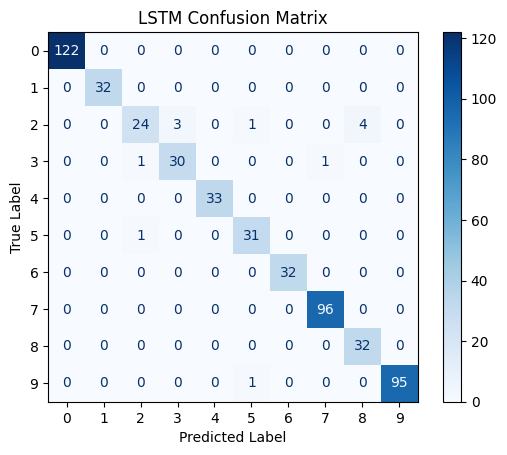

In [ ]:
plt.figure(figsize=(9, 9))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))

disp.plot(cmap="Blues", values_format="d")

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()